In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score,RepeatedStratifiedKFold
from sklearn.feature_selection import SelectKBest,chi2,mutual_info_classif,f_classif


In [3]:
train=pd.read_csv('/kaggle/input/titanic/train.csv',index_col='PassengerId')
test=pd.read_csv('/kaggle/input/titanic/test.csv')
submit=pd.DataFrame(test['PassengerId'])
test=test.set_index('PassengerId')

<AxesSubplot:xlabel='Pclass', ylabel='Survived'>

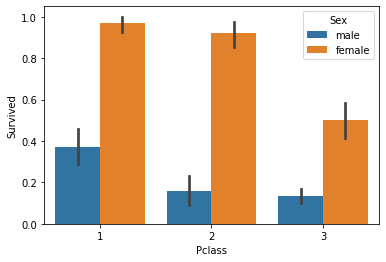

In [4]:
sns.barplot(x='Pclass',y='Survived',data=train,hue='Sex')  #Female of 1st class  and 2nd Class has higher chance to survive

<AxesSubplot:xlabel='Age', ylabel='Proportion'>

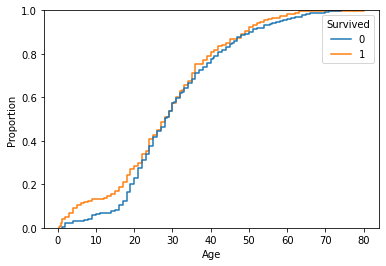

In [5]:
sns.ecdfplot(x='Age',data=train,hue='Survived')  # We can see that below age 10 it has chance of survival

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='Age', ylabel='Density'>

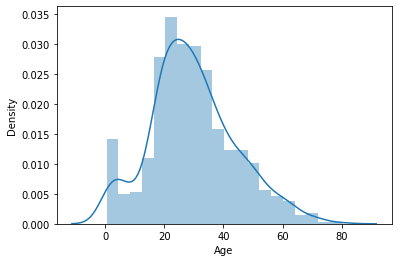

In [6]:
sns.distplot(train['Age'])   # we can see a rise in children columns

<AxesSubplot:xlabel='Fare', ylabel='Proportion'>

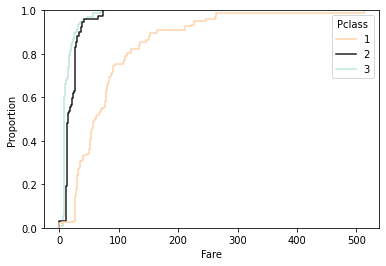

In [7]:
sns.ecdfplot(x=train['Fare'],hue=train['Pclass'],palette='icefire_r')  #about 80% of people paid fare less than 100

<AxesSubplot:xlabel='Fare', ylabel='Proportion'>

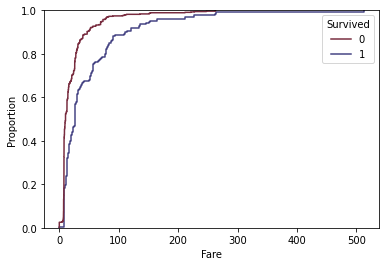

In [8]:
sns.ecdfplot(x=train['Fare'],hue=train['Survived'],palette='icefire_r')  #1 st class offer higher price

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


<AxesSubplot:xlabel='SibSp', ylabel='count'>

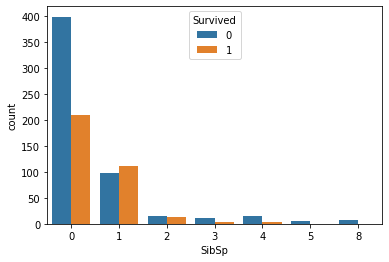

In [9]:
sns.countplot(train['SibSp'],hue=train['Survived'])  #More people who do no have no sibling has more chance to survive

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


<AxesSubplot:xlabel='Parch', ylabel='count'>

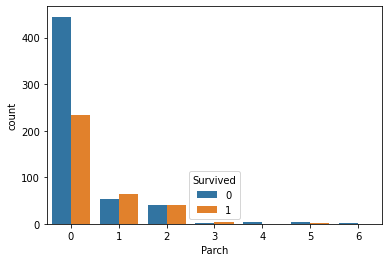

In [10]:
sns.countplot(train['Parch'],hue=train['Survived'])

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


<AxesSubplot:xlabel='pass_no', ylabel='count'>

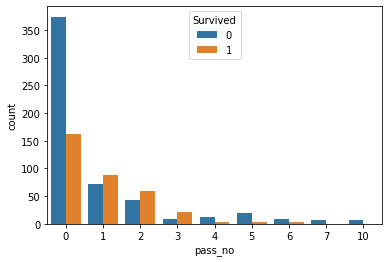

In [11]:
train['pass_no']=train['SibSp']+train['Parch']
sns.countplot(train['pass_no'],hue=train['Survived'])   # people with less than 3 people in family has more chance to survive

# Data Modelling

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


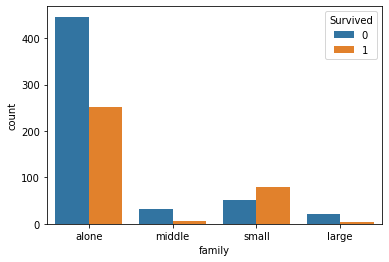

In [12]:
def family(size):
    a=''
    if(size<=1):
        a='alone'
    elif(size<=3):
        a='small'
    elif(size<=5):
        a='middle'
    else:
        a='large'
    return a
train['family']=train['pass_no'].map(family)
sns.countplot(train['family'],hue=train['Survived']) # alone has more chance to survive

train=pd.get_dummies(train,columns=['family'],drop_first=True)

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning
/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


<AxesSubplot:xlabel='age_group', ylabel='count'>

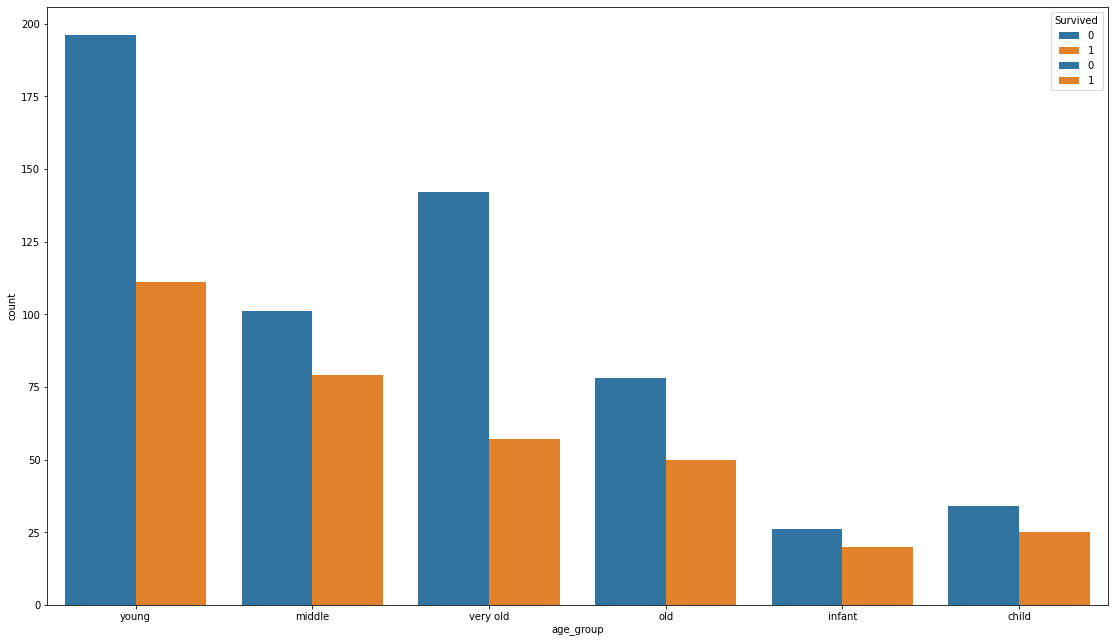

In [13]:
train['age_group']=pd.qcut(train['Age'],15)

plt.figure(figsize=(19,11))                               #  Age between 31 and 36 has more chance to survive
sns.countplot(train['age_group'],hue=train['Survived'])  #In age group we can see person with less than 14 age has chance to survive
              
def age_group(age):
    a=''
    if(age<=3):
        a='infant'
    elif(age<=14):
        a='child'
    elif(age<=29):
        a='young'
    elif(age<=40):
        a='middle'
    elif(age<=60):
        a='old'
    else:
        a='very old'
    return a
train['age_group']=train['Age'].map(age_group)
sns.countplot(train['age_group'],hue=train['Survived']) 
    

    
        
    
    
                    

In [14]:
train['Age']=train["Age"].fillna(train.groupby(['Pclass','Sex'])['Age'].transform("mean"))
train['Fare']=train["Fare"].fillna(train.groupby(['Pclass','Sex'])['Age'].transform("median"))


In [15]:
train['Sex']=train['Sex'].replace({'male':0,'female':1})
train=pd.get_dummies(train,columns=['Embarked'],drop_first=True)


train=train.drop(['Name','Ticket','Cabin'],axis=1)

In [16]:
train['age_group'].replace({'young':0,'very old':1,'middle':2,'old':3,'child':4,'infant':5},inplace=True)

# Modelling

In [17]:
x=train.drop('Survived',axis=1)
y=train['Survived']


for i in range(1,2):
    pipeline=Pipeline(steps=[('rfe',SelectKBest(score_func=chi2,k=13)),('encode',StandardScaler()),('model',GradientBoostingClassifier())])
    pipeline.fit(x,y)
    score=cross_val_score(pipeline,x,y,scoring='accuracy',n_jobs=-1)
    print(np.mean(score),i)

0.8316678174628084 1


# Applying on test columns

In [18]:
test['pass_no']=test['SibSp']+test['Parch']
test['family']=test['pass_no'].map(family)

test['age_group']=test['Age'].map(age_group)
test=pd.get_dummies(test,columns=['family','age_group','Embarked'],drop_first=True)

test['Sex']=test['Sex'].replace({'male':0,'female':1})
test=test.drop(['Name','Ticket','Cabin','pass_no'],axis=1)

test['Age']=test["Age"].fillna(test.groupby(['Pclass','Sex'])['Age'].transform("mean"))
test['Fare']=test["Fare"].fillna(test.groupby(['Pclass','Sex'])['Age'].transform("median"))
test['age_group'].replace({'young':0,'very old':1,'middle':2,'old':3,'child':4,'infant':5},inplace=True)

KeyError: 'age_group'

In [19]:
submit['Survived']=pipeline.predict(test)
submit.to_csv('ver1.csv',index=False)

ValueError: X has a different shape than during fitting.